# Pure Arbitrage: CME vs Prediction Markets

Modular notebook runner with research-style performance analysis for fixed-cost and dynamic-cost variants.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pure_arb_analytics import (
    build_monthly_pnl,
    compute_research_stats,
    plot_cumulative_and_drawdown,
    plot_monthly_bars,
    plot_trade_pnl_histogram,
    summarize_strategies,
)
from pure_arb_pipeline import OUT_DIR, build_panel_with_targets
from pure_arb_strategies import (
    FIXED_TC_BPS,
    N_CME_DEFAULT,
    run_dynamic_usd_strategy,
    run_fixed_bps_strategy,
)
from transaction_cost_models import CME_BPV_USD_PER_BP, build_adv_lookup

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
df_ff, realized_change, actual_decision, effr_meetings = build_panel_with_targets()
print("rows", len(df_ff), "meetings", df_ff["decision_date"].nunique())
print("effr observations", int(df_ff["effr_expected_bps"].notna().sum()))
print("effr meetings", len(effr_meetings))
print("realized keys", len(realized_change), "actual keys", len(actual_decision))


rows 2484 meetings 30
effr observations 898
effr meetings 12
realized keys 28 actual keys 27


In [3]:
trades_fixed = run_fixed_bps_strategy(
    df=df_ff,
    meetings=effr_meetings,
    realized_change=realized_change,
    actual_decision=actual_decision,
    tc_bps=FIXED_TC_BPS,
)
print("fixed trades", len(trades_fixed))
display(trades_fixed.head(20) if not trades_fixed.empty else trades_fixed)


fixed trades 51


,meeting,entry_date,exit_date,spread_at_entry_bps,direction,pnl_theoretical_bps,pnl_actual_bps,spread_at_settle_bps,days_held
0,2024-09-18,2024-07-30,2024-09-18,29.273225,Short Kalshi / Long CME,25.273225,25.273225,1.136868e-13,50
1,2024-09-18,2024-07-31,2024-09-18,4.783163,Short Kalshi / Long CME,0.783163,0.783163,1.136868e-13,49
2,2024-09-18,2024-08-01,2024-09-18,11.286630,Short Kalshi / Long CME,7.286630,7.286630,1.136868e-13,48
3,2024-09-18,2024-08-02,2024-09-18,11.362559,Short Kalshi / Long CME,7.362559,7.362559,1.136868e-13,47
4,2024-09-18,2024-08-05,2024-09-18,15.314055,Short Kalshi / Long CME,11.314055,11.314055,1.136868e-13,44
5,2024-09-18,2024-08-06,2024-09-18,11.936620,Short Kalshi / Long CME,7.936620,7.936620,1.136868e-13,43
6,2024-09-18,2024-08-07,2024-09-18,12.630208,Short Kalshi / Long CME,8.630208,8.630208,1.136868e-13,42
7,2024-09-18,2024-08-08,2024-09-18,8.331186,Short Kalshi / Long CME,4.331186,4.331186,1.136868e-13,41
8,2024-09-18,2024-08-09,2024-09-18,8.639706,Short Kalshi / Long CME,4.639706,4.639706,1.136868e-13,40
9,2024-09-18,2024-08-12,2024-09-18,12.998879,Short Kalshi / Long CME,8.998879,8.998879,1.136868e-13,37


In [4]:
vol_lookup, monthly_adv = build_adv_lookup()
trades_usd = run_dynamic_usd_strategy(
    df=df_ff,
    meetings=effr_meetings,
    realized_change=realized_change,
    actual_decision=actual_decision,
    vol_lookup=vol_lookup,
    monthly_adv_lookup=monthly_adv,
    n_cme=N_CME_DEFAULT,
)

cand = []
for meeting in effr_meetings:
    mdf = df_ff[df_ff["decision_date"] == meeting].sort_values("observed_day_pst")
    mdf = mdf[mdf["poly_expected_bps"].notna() & mdf["effr_expected_bps"].notna()].copy()
    for _, row in mdf.iterrows():
        spread = abs(float(row["poly_expected_bps"] - row["effr_expected_bps"]))
        cand.append(spread * CME_BPV_USD_PER_BP * N_CME_DEFAULT)

if cand:
    print("Median gross edge USD:", float(np.median(cand)))
    print("95th pct gross edge USD:", float(np.percentile(cand, 95)))
print("dynamic trades", len(trades_usd))
display(trades_usd.head(20) if not trades_usd.empty else trades_usd)


Median gross edge USD: 72.41348918887684
95th pct gross edge USD: 244.3999555245761
dynamic trades 66


,meeting,entry_date,exit_date,direction,spread_entry_bps,spread_settle_bps,days_held,n_cme,pm_total_abs_shares,pm_tc_round_trip_usd,cme_tc_round_trip_usd,total_tc_usd,gross_theoretical_usd,net_theoretical_usd,pm_leg_pnl_usd,cme_leg_pnl_usd,gross_actual_usd,net_actual_usd,pm_portfolio_weights
0,2023-10-31,2023-09-19,2023-10-31,Short PM / Long CME,4.250000,0.000000e+00,42,1,1041.75,20.835,0.017634,20.852634,177.097500,156.244866,468.787500,-291.69000,177.097500,156.244866,"{'polymarket_H0': 0.0, 'polymarket_H25': 1.0}"
1,2023-10-31,2023-09-20,2023-10-31,Long PM / Short CME,-2.851759,0.000000e+00,41,1,1041.75,20.835,0.016934,20.851934,118.832789,97.980855,-192.723750,312.52500,119.801250,98.949316,"{'polymarket_H0': 0.0, 'polymarket_H25': 1.0}"
2,2023-10-31,2023-09-21,2023-10-31,Long PM / Short CME,-2.226131,0.000000e+00,40,1,1041.75,20.835,0.017121,20.852121,92.762864,71.910743,-197.932500,291.69000,93.757500,72.905379,"{'polymarket_H0': 0.0, 'polymarket_H25': 1.0}"
3,2023-10-31,2023-09-22,2023-10-31,Long PM / Short CME,-1.273632,0.000000e+00,39,1,1041.75,20.835,0.017477,20.852477,53.072239,32.219762,-197.932500,250.02000,52.087500,31.235023,"{'polymarket_H0': 0.0, 'polymarket_H25': 1.0}"
4,2023-10-31,2023-10-02,2023-10-31,Short PM / Long CME,1.450000,0.000000e+00,29,1,1041.75,20.835,0.017431,20.852431,60.421500,39.569069,364.612500,-304.19100,60.421500,39.569069,"{'polymarket_H0': 0.0, 'polymarket_H25': 1.0}"
5,2023-10-31,2023-10-03,2023-10-31,Long PM / Short CME,-0.934343,0.000000e+00,28,1,1041.75,20.835,0.017282,20.852282,38.934091,18.081809,-270.855000,312.52500,41.670000,20.817718,"{'polymarket_H0': 0.0, 'polymarket_H25': 1.0}"
6,2023-10-31,2023-10-04,2023-10-31,Short PM / Long CME,0.575000,0.000000e+00,27,1,1041.75,20.835,0.017470,20.852470,23.960250,3.107780,244.811250,-220.85100,23.960250,3.107780,"{'polymarket_H0': 0.0, 'polymarket_H25': 1.0}"
7,2023-10-31,2023-10-06,2023-10-31,Long PM / Short CME,-1.154822,0.000000e+00,25,1,1041.75,20.835,0.017851,20.852851,48.121447,27.268596,-260.437500,312.52500,52.087500,31.234649,"{'polymarket_H0': 0.0, 'polymarket_H25': 1.0}"
8,2023-10-31,2023-10-10,2023-10-31,Long PM / Short CME,-0.688060,0.000000e+00,21,1,1041.75,20.835,0.018088,20.853088,28.671448,7.818360,-109.383750,137.51100,28.127250,7.274162,"{'polymarket_H0': 0.0, 'polymarket_H25': 1.0}"
9,2023-10-31,2023-10-11,2023-10-31,Short PM / Long CME,1.569767,0.000000e+00,20,1,1041.75,20.835,0.018285,20.853285,65.412209,44.558924,182.306250,-104.17500,78.131250,57.277965,"{'polymarket_H0': 0.0, 'polymarket_H25': 1.0}"


In [5]:
fixed_monthly_theo = build_monthly_pnl(trades_fixed, pnl_col="pnl_theoretical_bps", date_col="exit_date", label="fixed_theoretical")
fixed_monthly_actual = build_monthly_pnl(trades_fixed, pnl_col="pnl_actual_bps", date_col="exit_date", label="fixed_actual")
dyn_monthly_theo = build_monthly_pnl(trades_usd, pnl_col="net_theoretical_usd", date_col="exit_date", label="dynamic_theoretical")
dyn_monthly_actual = build_monthly_pnl(trades_usd, pnl_col="net_actual_usd", date_col="exit_date", label="dynamic_actual")

stats_table = summarize_strategies({
    "fixed_theoretical_bps": compute_research_stats(trades_fixed, pnl_col="pnl_theoretical_bps", date_col="exit_date"),
    "fixed_actual_bps": compute_research_stats(trades_fixed, pnl_col="pnl_actual_bps", date_col="exit_date"),
    "dynamic_theoretical_usd": compute_research_stats(trades_usd, pnl_col="net_theoretical_usd", date_col="exit_date"),
    "dynamic_actual_usd": compute_research_stats(trades_usd, pnl_col="net_actual_usd", date_col="exit_date"),
})
display(stats_table.round(4))


,n_trades,total_pnl,mean_trade_pnl,median_trade_pnl,std_trade_pnl,win_rate,profit_factor,avg_holding_days,monthly_mean_pnl,monthly_vol_pnl,monthly_sharpe_ann,monthly_sortino_ann,max_monthly_drawdown,best_month_pnl,worst_month_pnl,n_months
strategy,,,,,,,,,,,,,,,,
fixed_theoretical_bps,51.0,211.0083,4.1374,1.3450,6.6694,1.0000,NaN,70.0000,35.1680,45.8993,2.6542,NaN,0.0000,108.4530,2.3041,6.0
fixed_actual_bps,40.0,212.7040,5.3176,2.5423,7.7596,0.9250,23.3140,59.6250,42.5408,55.5431,2.6532,NaN,-5.3497,108.4530,-5.3497,5.0
dynamic_theoretical_usd,66.0,6901.0964,104.5621,42.7479,139.4315,1.0000,NaN,31.8030,862.6371,1404.5073,2.1276,NaN,0.0000,4110.3925,6.4872,8.0
dynamic_actual_usd,61.0,3577.3901,58.6457,39.5691,131.2266,0.7377,3.6456,27.7213,596.2317,1687.4913,1.2240,22.9688,-1352.1802,3858.2766,-739.6747,6.0


In [6]:
monthly_table = (
    fixed_monthly_theo[["month", "pnl"]].rename(columns={"pnl": "fixed_theoretical_bps"})
    .merge(fixed_monthly_actual[["month", "pnl"]].rename(columns={"pnl": "fixed_actual_bps"}), on="month", how="outer")
    .merge(dyn_monthly_theo[["month", "pnl"]].rename(columns={"pnl": "dynamic_theoretical_usd"}), on="month", how="outer")
    .merge(dyn_monthly_actual[["month", "pnl"]].rename(columns={"pnl": "dynamic_actual_usd"}), on="month", how="outer")
    .sort_values("month")
)
display(monthly_table.round(4))


,month,fixed_theoretical_bps,fixed_actual_bps,dynamic_theoretical_usd,dynamic_actual_usd
0,2023-10-31,NaN,NaN,602.2645,622.6782
1,2024-09-30,108.4530,108.4530,4110.3925,3858.2766
2,2024-11-30,8.6431,8.6431,NaN,NaN
3,2025-07-31,NaN,NaN,30.9756,31.7561
4,2025-09-30,NaN,NaN,242.0085,416.8594
5,2025-10-31,2.3041,-5.3497,172.5866,-612.5055
6,2025-12-31,77.3527,97.5273,194.8741,-739.6747
7,2026-01-31,3.4303,3.4303,NaN,NaN
8,2026-03-31,10.8251,NaN,6.4872,NaN
9,2026-04-30,NaN,NaN,1541.5075,NaN


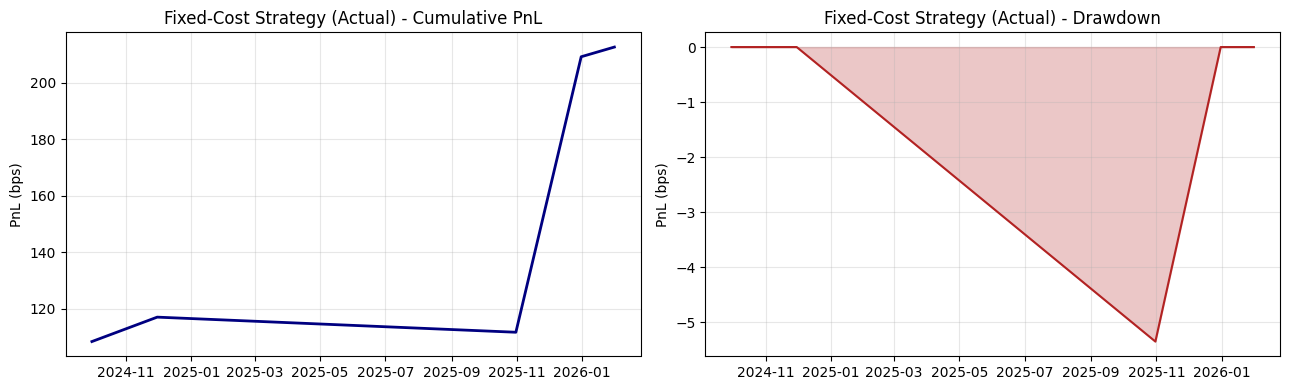

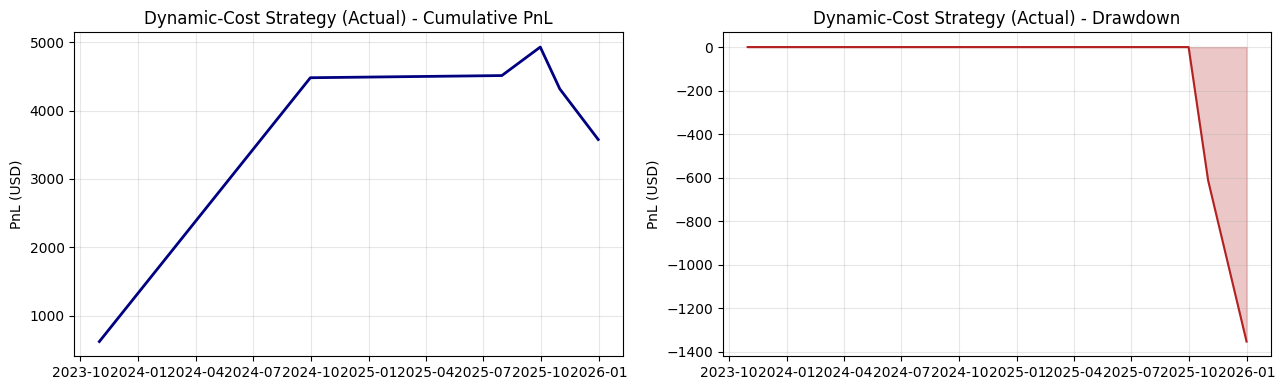

In [7]:
plot_cumulative_and_drawdown(fixed_monthly_actual, "Fixed-Cost Strategy (Actual)", "PnL (bps)")
plt.show()

plot_cumulative_and_drawdown(dyn_monthly_actual, "Dynamic-Cost Strategy (Actual)", "PnL (USD)")
plt.show()


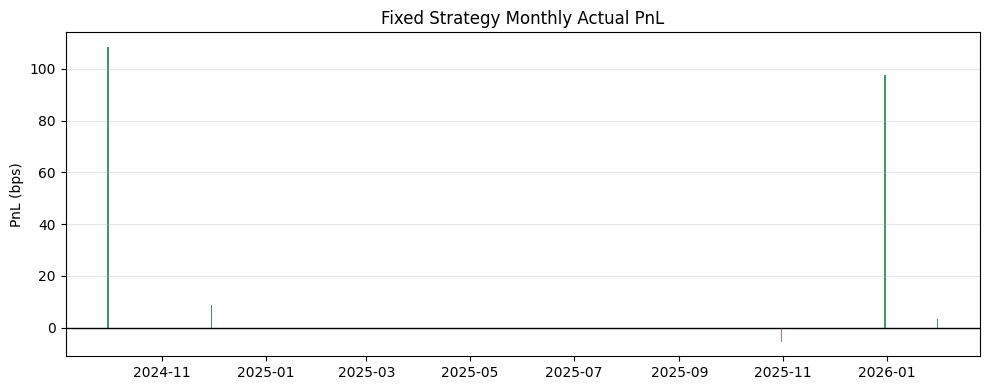

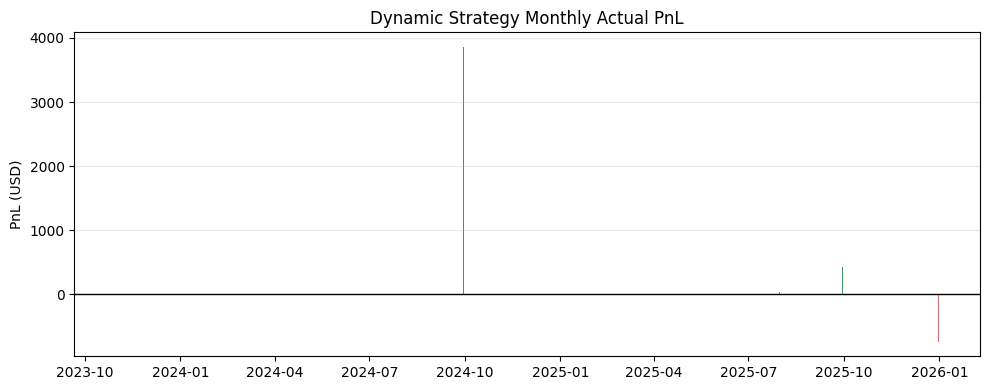

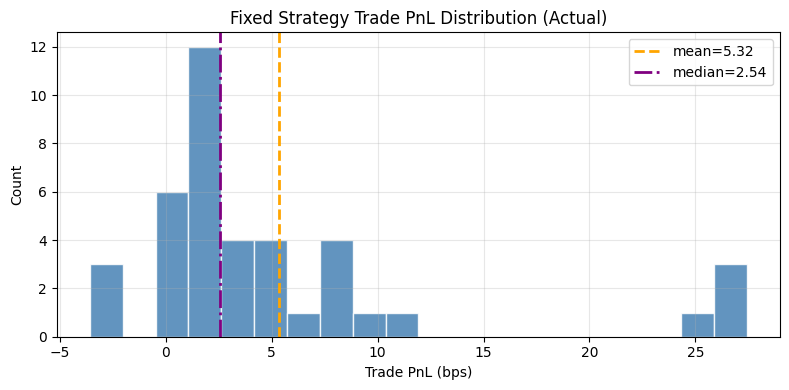

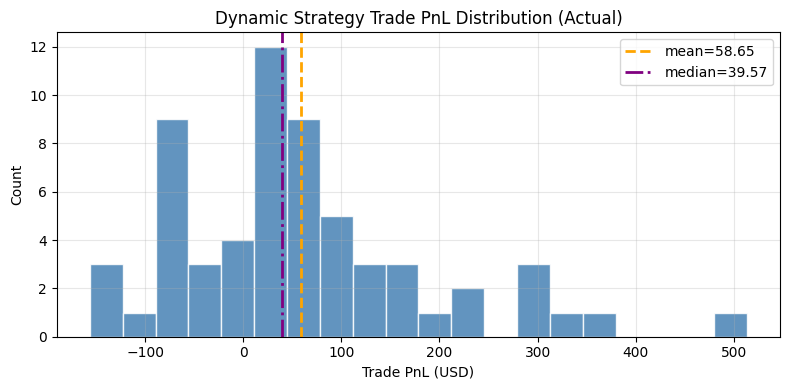

In [8]:
plot_monthly_bars(fixed_monthly_actual, "Fixed Strategy Monthly Actual PnL", "PnL (bps)")
plt.show()

plot_monthly_bars(dyn_monthly_actual, "Dynamic Strategy Monthly Actual PnL", "PnL (USD)")
plt.show()

plot_trade_pnl_histogram(
    trades_fixed,
    pnl_col="pnl_actual_bps",
    title="Fixed Strategy Trade PnL Distribution (Actual)",
    x_label="Trade PnL (bps)",
)
plt.show()

plot_trade_pnl_histogram(
    trades_usd,
    pnl_col="net_actual_usd",
    title="Dynamic Strategy Trade PnL Distribution (Actual)",
    x_label="Trade PnL (USD)",
)
plt.show()


In [9]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
if not trades_fixed.empty:
    trades_fixed.to_csv(OUT_DIR / "trades_fixed_tc_bps.csv", index=False)
if not trades_usd.empty:
    trades_usd.to_csv(OUT_DIR / "trades_dynamic_tc_usd.csv", index=False)
if not stats_table.empty:
    stats_table.to_csv(OUT_DIR / "performance_stats_research_style.csv")
if not monthly_table.empty:
    monthly_table.to_csv(OUT_DIR / "monthly_pnl_research_style.csv", index=False)

summary = {
    "fixed_n_trades": int(len(trades_fixed)) if not trades_fixed.empty else 0,
    "fixed_total_theoretical_bps": float(trades_fixed["pnl_theoretical_bps"].sum()) if not trades_fixed.empty else 0.0,
    "fixed_total_actual_bps": float(trades_fixed["pnl_actual_bps"].sum()) if (not trades_fixed.empty and trades_fixed["pnl_actual_bps"].notna().any()) else np.nan,
    "dynamic_n_trades": int(len(trades_usd)) if not trades_usd.empty else 0,
    "dynamic_total_theoretical_usd": float(trades_usd["net_theoretical_usd"].sum()) if not trades_usd.empty else 0.0,
    "dynamic_total_actual_usd": float(trades_usd["net_actual_usd"].sum()) if (not trades_usd.empty and trades_usd["net_actual_usd"].notna().any()) else np.nan,
}
summary


{'fixed_n_trades': 51,
 'fixed_total_theoretical_bps': 211.00828244208896,
 'fixed_total_actual_bps': 212.70402681902033,
 'dynamic_n_trades': 66,
 'dynamic_total_theoretical_usd': 6901.096407301289,
 'dynamic_total_actual_usd': 3577.3900820998997}